In [12]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cirrhosis_patient_survival_prediction = fetch_ucirepo(id=878) 
  
# data (as pandas dataframes) 
X = cirrhosis_patient_survival_prediction.data.features 
y = cirrhosis_patient_survival_prediction.data.targets 

In [13]:
# metadata
cirrhosis_patient_survival_prediction.metadata

{'uci_id': 878,
 'name': 'Cirrhosis Patient Survival Prediction',
 'repository_url': 'https://archive.ics.uci.edu/dataset/878/cirrhosis+patient+survival+prediction+dataset-1',
 'data_url': 'https://archive.ics.uci.edu/static/public/878/data.csv',
 'abstract': 'Utilize 17 clinical features for predicting survival state of patients with liver cirrhosis. The survival states include 0 = D (death), 1 = C (censored), 2 = CL (censored due to liver transplantation).',
 'area': 'Health and Medicine',
 'tasks': ['Classification'],
 'characteristics': ['Tabular'],
 'num_instances': 418,
 'num_features': 17,
 'feature_types': ['Real', 'Categorical'],
 'demographics': ['Age', 'Sex'],
 'target_col': ['Status'],
 'index_col': ['ID'],
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1989,
 'last_updated': 'Fri Nov 03 2023',
 'dataset_doi': '10.24432/C5R02G',
 'creators': ['E. Dickson',
  'P. Grambsch',
  'T. Fleming',
  'L. Fisher',
  'A. Langworthy'],
 'intr

In [14]:
# variables
cirrhosis_patient_survival_prediction.variables

,name,role,type,demographic,description,units,missing_values
0,ID,ID,Integer,NaN,unique identifier,NaN,no
1,N_Days,Other,Integer,NaN,number of days between registration and the ea...,NaN,no
2,Status,Target,Categorical,NaN,"status of the patient C (censored), CL (censor...",NaN,no
3,Drug,Feature,Categorical,NaN,type of drug D-penicillamine or placebo,NaN,yes
4,Age,Feature,Integer,Age,age,days,no
5,Sex,Feature,Categorical,Sex,M (male) or F (female),NaN,no
6,Ascites,Feature,Categorical,NaN,presence of ascites N (No) or Y (Yes),NaN,yes
7,Hepatomegaly,Feature,Categorical,NaN,presence of hepatomegaly N (No) or Y (Yes),NaN,yes
8,Spiders,Feature,Categorical,NaN,presence of spiders N (No) or Y (Yes),NaN,yes
9,Edema,Feature,Categorical,NaN,presence of edema N (no edema and no diuretic ...,NaN,no


In [15]:

import numpy as np
import pandas as pd

X["Cholesterol"] = X["Cholesterol"].replace("NaNN", np.nan)
X["Cholesterol"] = pd.to_numeric(X["Cholesterol"], errors="coerce")

X["Copper"] = X["Copper"].replace("NaNN", np.nan)
X["Copper"] = pd.to_numeric(X["Copper"], errors="coerce")

X["Tryglicerides"] = X["Tryglicerides"].replace("NaNN", np.nan)
X["Tryglicerides"] = pd.to_numeric(X["Tryglicerides"], errors="coerce")

X["Platelets"] = X["Platelets"].replace("NaNN", np.nan)
X["Platelets"] = pd.to_numeric(X["Platelets"], errors="coerce")

X["Stage"] = X["Stage"].astype("category")

In [16]:
cat_cols = X.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    print(f"\n===== {col} =====")
    print("\nunique:", X[col].dropna().unique())
    print("\ncounts:\n", X[col].value_counts(dropna=False))


===== Drug =====

unique: <StringArray>
['D-penicillamine', 'Placebo', 'NaNN']
Length: 3, dtype: str

counts:
 Drug
D-penicillamine    158
Placebo            154
NaN                105
NaNN                 1
Name: count, dtype: int64

===== Sex =====

unique: <StringArray>
['F', 'M']
Length: 2, dtype: str

counts:
 Sex
F    374
M     44
Name: count, dtype: int64

===== Ascites =====

unique: <StringArray>
['Y', 'N', 'NaNN']
Length: 3, dtype: str

counts:
 Ascites
N       288
NaN     105
Y        24
NaNN      1
Name: count, dtype: int64

===== Hepatomegaly =====

unique: <StringArray>
['Y', 'N', 'NaNN']
Length: 3, dtype: str

counts:
 Hepatomegaly
Y       160
N       152
NaN     105
NaNN      1
Name: count, dtype: int64

===== Spiders =====

unique: <StringArray>
['Y', 'N', 'NaNN']
Length: 3, dtype: str

counts:
 Spiders
N       222
NaN     105
Y        90
NaNN      1
Name: count, dtype: int64

===== Edema =====

unique: <StringArray>
['Y', 'N', 'S']
Length: 3, dtype: str

counts:
 Ede

C:\Users\jestg\AppData\Local\Temp\ipykernel_45788\3783347064.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns


In [17]:
num_cols = X.select_dtypes(include=["number"]).columns

summary = X[num_cols].agg(["min", "mean", "median", "max", "std"]).T
summary

,min,mean,median,max,std
Age,9598.00,18533.351675,18628.00,28650.00,3815.845055
Bilirubin,0.30,3.220813,1.40,28.00,4.407506
Cholesterol,120.00,369.510563,309.50,1775.00,231.944545
Albumin,1.96,3.497440,3.53,4.64,0.424972
Copper,4.00,97.648387,73.00,588.00,85.613920
Alk_Phos,289.00,1982.655769,1259.00,13862.40,2140.388824
SGOT,26.35,122.556346,114.70,457.25,56.699525
Tryglicerides,33.00,124.702128,108.00,598.00,65.148639
Platelets,62.00,257.024570,251.00,721.00,98.325585
Prothrombin,9.00,10.731731,10.60,18.00,1.022000


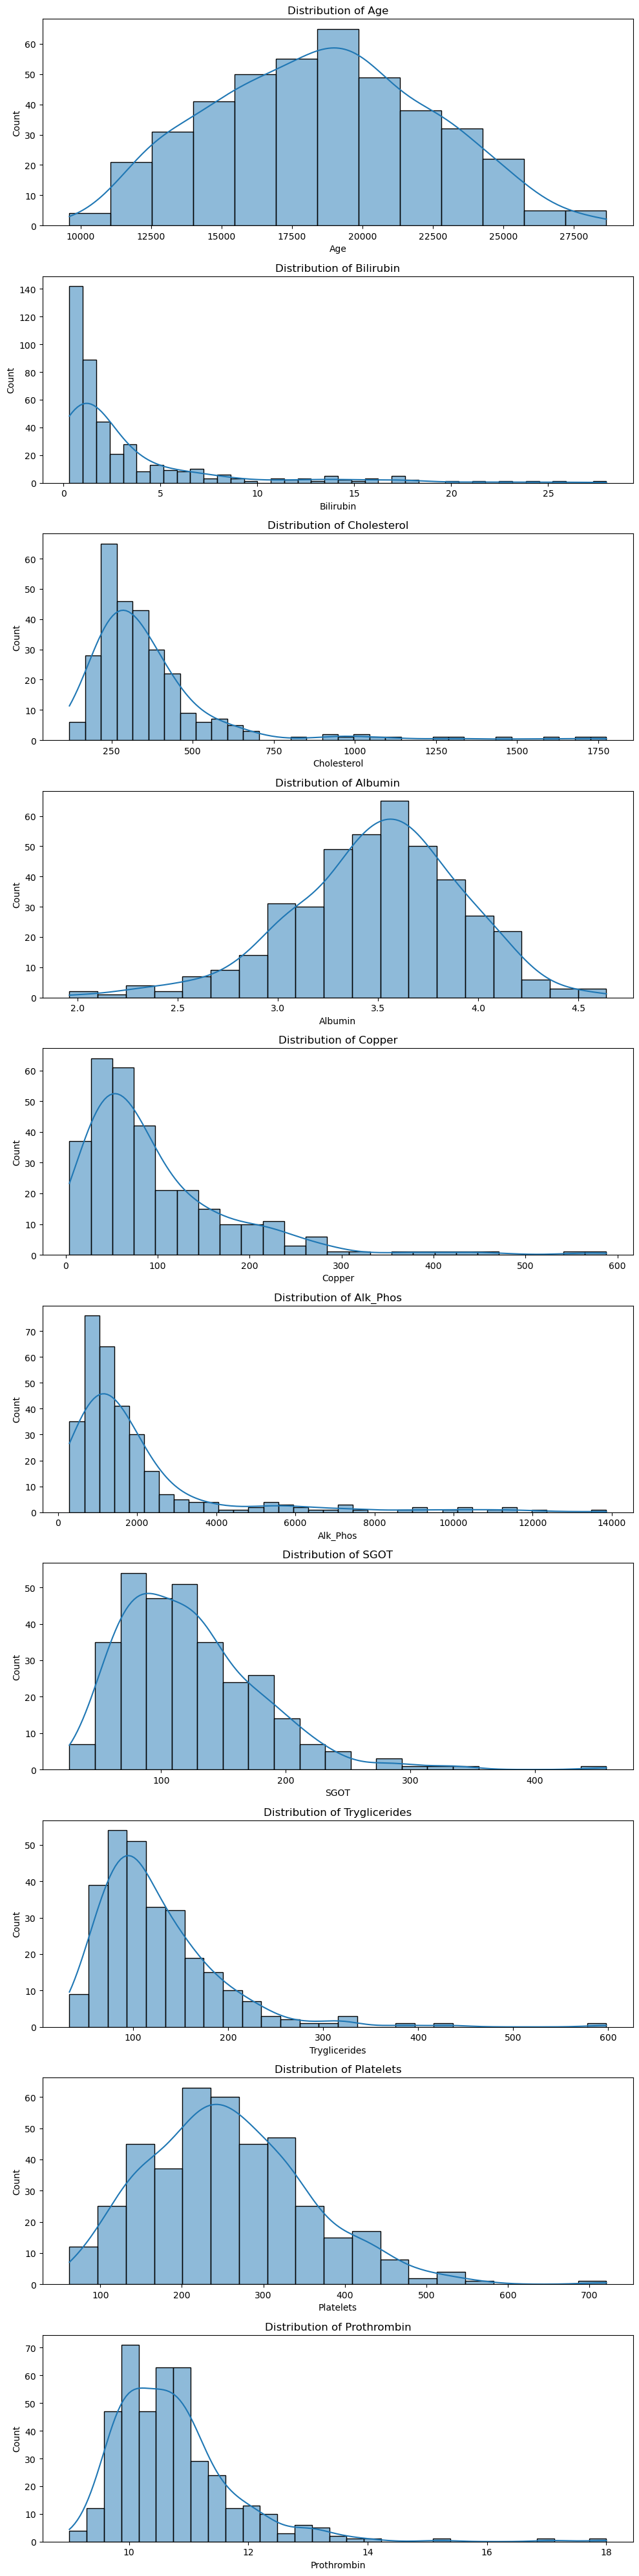

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = X.select_dtypes(include=["number"]).columns

fig, axes = plt.subplots(len(num_cols), 1, figsize=(10, 4 * len(num_cols)))

if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    sns.histplot(X[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [19]:
print(y.head())
print()
print(y.dtypes)
print()
print(y.isna().sum())
print()
print(y.value_counts(dropna=False))

  Status
0      D
1      C
2      D
3      D
4     CL

Status    str
dtype: object

Status    0
dtype: int64

Status
C         232
D         161
CL         25
Name: count, dtype: int64


In [20]:
X.isna().sum().sort_values(ascending=False)

Tryglicerides    136
Cholesterol      134
Copper           108
Alk_Phos         106
SGOT             106
Drug             105
Hepatomegaly     105
Spiders          105
Ascites          105
Platelets         11
Stage              6
Prothrombin        2
Age                0
Bilirubin          0
Edema              0
Sex                0
Albumin            0
dtype: int64

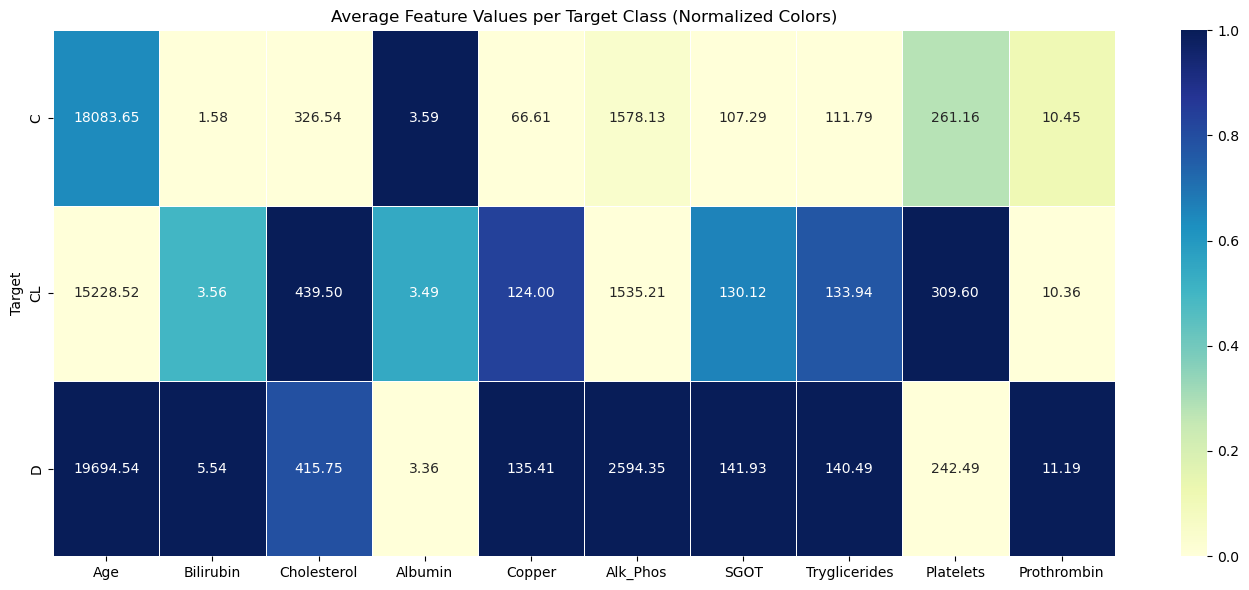

In [29]:
from sklearn.preprocessing import MinMaxScaler

df = X.select_dtypes(include=["number"]).copy()
df["Target"] = y

grouped_df = df.groupby("Target").mean()

scaler = MinMaxScaler()
grouped_scaled = pd.DataFrame(
    scaler.fit_transform(grouped_df),
    columns=grouped_df.columns,
    index=grouped_df.index,
)

plt.figure(figsize=(14, 6))
sns.heatmap(grouped_scaled, annot=grouped_df, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.title("Average Feature Values per Target Class (Normalized Colors)")
plt.tight_layout()
plt.show()

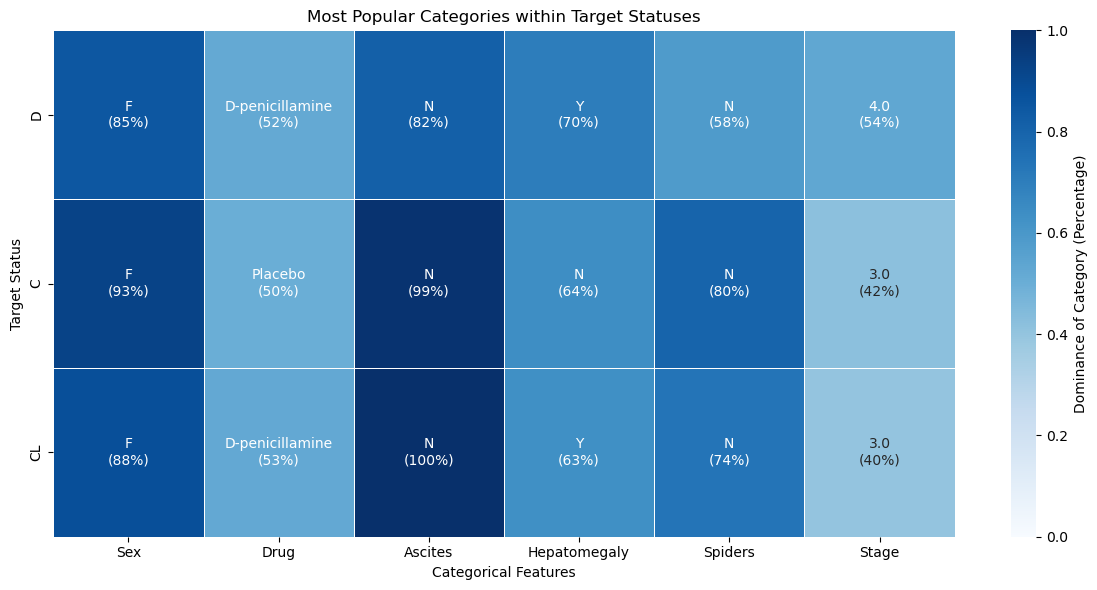

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

categorical_cols = ["Sex", "Drug", "Ascites", "Hepatomegaly", "Spiders", "Stage"]

df_cat = X[categorical_cols].copy()
df_cat["Target"] = y

text_matrix = pd.DataFrame(index=df_cat["Target"].unique(), columns=categorical_cols)
numeric_matrix = pd.DataFrame(index=df_cat["Target"].unique(), columns=categorical_cols)

for target_val in df_cat["Target"].unique():
    df_sub = df_cat[df_cat["Target"] == target_val]
    
    for col in categorical_cols:
        value_counts = df_sub[col].value_counts(normalize=True)
        if not value_counts.empty:
            most_popular_name = value_counts.index[0]
            percentage = value_counts.iloc[0]
            
            text_matrix.loc[target_val, col] = f"{most_popular_name}\n({percentage:.0%})"
            numeric_matrix.loc[target_val, col] = percentage

numeric_matrix = numeric_matrix.astype(float)

plt.figure(figsize=(12, 6))
sns.heatmap(
    numeric_matrix,
    annot=text_matrix,  
    fmt="",            
    cmap="Blues",        
    vmin=0, vmax=1,      
    linewidths=0.5,
    cbar_kws={'label': 'Dominance of Category (Percentage)'}
)

plt.ylabel("Target Status")
plt.xlabel("Categorical Features")
plt.title("Most Popular Categories within Target Statuses")
plt.tight_layout()
plt.show()